# 12 - Voting Classifier

Combines the top performing individual models by averaging their predicted probabilities (soft voting) - the idea being that models with different inductive biases (linear, tree based, boosting) tend to make different mistakes, so averaging can smooth out individual weaknesses.

This notebook automatically selects the top performing models from already run comparison, rather than guessing upfront which ones to combine. 


## Setup

In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Rank eligible models by validation Recall and select the top performers

In [8]:
import json
import pandas as pd
from pathlib import Path

# baseline and the PyTorch neural network are excluded (different interfaces entirely)
eligible_metrics_files = {
    'Logistic Regression': '../../../data/processed/metrics_logreg.json',
    'SVM (Linear)': '../../../data/processed/metrics_svm.json',
    'AdaBoost': '../../../data/processed/metrics_adaboost.json',
    'Gradient Boosting': '../../../data/processed/metrics_gb.json',
    'Random Forest': '../../../data/processed/metrics_rf.json',
    'XGBoost': '../../../data/processed/metrics_xgb.json',
    'LightGBM': '../../../data/processed/metrics_lightgbm.json',
    'CatBoost': '../../../data/processed/metrics_catboost.json',
}

ranked = []
for name, path in eligible_metrics_files.items():
    with open(path) as f:
        m = json.load(f)
    ranked.append(m)

ranked_df = pd.DataFrame(ranked).set_index('model').sort_values('recall', ascending=False)
print("Eligible models ranked by validation Recall:")
print(ranked_df[['recall', 'precision', 'f1', 'roc_auc']])

TOP_N = 4
top_models = ranked_df.head(TOP_N).index.tolist()
print(f"\nSelected top {TOP_N} models for the ensemble: {top_models}")


Eligible models ranked by validation Recall:
                               recall  precision        f1   roc_auc
model                                                               
Random Forest                0.617200   0.792379  0.693904  0.758014
XGBoost                      0.606216   0.815980  0.695629  0.759467
LightGBM                     0.601075   0.823567  0.694947  0.764321
CatBoost                     0.593597   0.835801  0.694179  0.764244
Gradient Boosting (sklearn)  0.591727   0.840917  0.694650  0.763873
AdaBoost                     0.569526   0.836307  0.677603  0.739317
SVM (Linear)                 0.561814   0.839385  0.673107  0.739186
Logistic Regression          0.554335   0.837866  0.667229  0.739404

Selected top 4 models for the ensemble: ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


**What we found:**

**The top 4 models selected were Random Forest, XGBoost, LightGBM, and CatBoost, all tree based ensembles, no linear model made the cut.** Logistic Regression and SVM both ranked at the bottom of the eligible list (Recall 0.554 and 0.562 respectively, well below the tree based cluster's 0.59 to 0.62 range), so the automatic top 4 selection excluded them entirely.

**This is worth flagging as a real limitation before even looking at the ensemble's results below:** these four models likely make *correlated* errors, they're all tree ensembles trained on the same feature set, so when one gets an order wrong, the others are more likely to get it wrong too, for similar reasons. Voting works best when the combined models have genuinely different failure patterns (which is exactly why a linear model like Logistic Regression, with a fundamentally different decision boundary, would have been a valuable addition to the mix). Picking purely by Recall ranking optimized for individual strength, not for ensemble diversity, and those aren't always the same thing.


## 2. Build and train the Voting Classifier

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


model_builders = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, random_state=42),
    'SVM (Linear)': lambda: CalibratedClassifierCV(LinearSVC(max_iter=5000, random_state=42), cv=3),
    'AdaBoost': lambda: AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    'Gradient Boosting': lambda: GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lambda: LGBMClassifier(n_estimators=200, max_depth=-1, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': lambda: CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=False),
}

estimators = [(name.lower().replace(' ', '_').replace('(', '').replace(')', ''), model_builders[name]())
              for name in top_models]
print(f"Built {len(estimators)} fresh estimator instances for ensembling: {[e[0] for e in estimators]}")


Built 4 fresh estimator instances for ensembling: ['random_forest', 'xgboost', 'lightgbm', 'catboost']


In [10]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
voting_clf.fit(X_train, y_train)

y_pred = voting_clf.predict(X_val)
y_score = voting_clf.predict_proba(X_val)[:, 1]


## 3. Evaluate on the validation set

In [11]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()
    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Voting Classifier (validation set) ---
  recall: 0.5966
  precision: 0.8321
  f1: 0.6950
  roc_auc: 0.7616
  pr_auc: 0.8276

              precision    recall  f1-score   support

 On time (0)       0.64      0.86      0.73      3611
    Late (1)       0.83      0.60      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.71      7890
weighted avg       0.75      0.72      0.71      7890



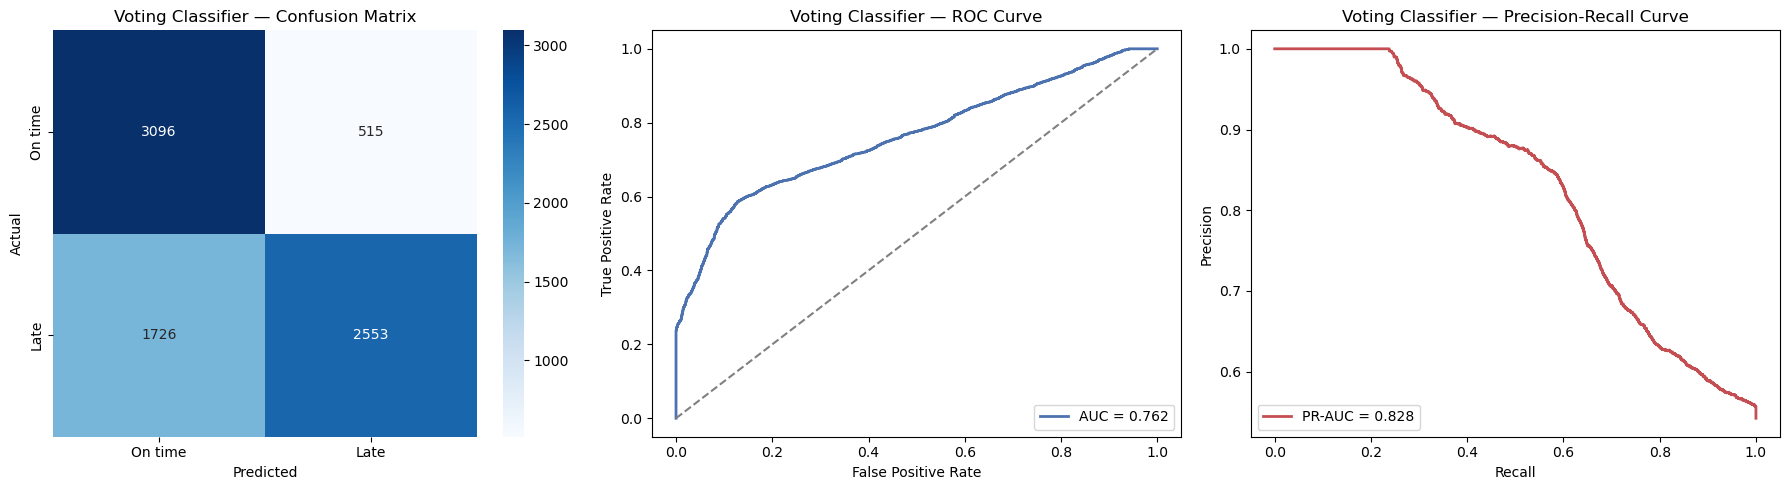

In [12]:
voting_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Voting Classifier', save_prefix='voting')


**What we found: ensembling made things worse on the metric that matters most, and the lack of diversity flagged above is almost certainly why.**

| Metric | Random Forest (best individual) | Voting Classifier | Change |
|---|---|---|---|
| Recall | **0.6172** | 0.5966 | **-0.0206** |
| Precision | 0.7924 | 0.8321 | +0.0397 |
| F1 | 0.6939 | 0.6950 | +0.0011 |
| ROC-AUC | 0.7580 | 0.7616 | +0.0036 |
| PR-AUC | 0.8234 | 0.8276 | +0.0042 |

**The Voting Classifier's Recall is actually lower than Random Forest alone**, a meaningful 2 point drop, even though F1, ROC-AUC, and PR-AUC all improved marginally. This is exactly the honest, legitimate "ensembling didn't help on our primary metric" finding we flagged as a real possibility going in, and it makes sense given Section 1's finding: averaging Random Forest's relatively aggressive, high Recall predictions together with three boosting models that all individually favor Precision over Recall pulls the combined prediction toward the more conservative, lower Recall consensus. The ensemble isn't wrong to do this, soft voting is mathematically just an average, but it means the specific behavior that made Random Forest attractive (catching more actual late orders) gets diluted by combining it with models that don't share that behavior.

**Conclusion: given our stated priority is Recall specifically, Random Forest alone currently outperforms this Voting ensemble, and the added complexity of maintaining four models in production isn't justified by the result.** 


## 4. Save model and metrics

In [13]:
joblib.dump(voting_clf, '../../../models/voting_classifier.pkl')
save_metrics(voting_metrics, '../../../data/processed/metrics_voting.json')


Saved metrics to ../../../data/processed/metrics_voting.json
